# Stage 10 — Final Mars model-input generation

_Pipeline stage 10 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## Mars model inputs — same patches, frozen CNN

Mars geometry (topology→pairs→features) is shared across regimes and raster-
independent. The raster-dependent part — **5-class patches** — is regenerated with the
*current* rasterizer so it matches the Earth patches the CNN trained on, then embedded
with the **frozen** `cnn_outlet_final.pt`. Patches **must stay 5-class**. We check
coverage, the patches themselves, and the resulting Mars embedding distribution
(vs Earth, to confirm the domains overlap).

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
def _load_op_thr(r):  # per-regime operating threshold, read from disk (auto-tracks retrains)
    p = MODELS / f'optimal_threshold_geom_plus_cnn_emb_{r}.txt'
    return float(p.read_text().strip()) if p.exists() else float('nan')
OP_THR = {r: _load_op_thr(r) for r in REGIMES_}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### 1 · Patch coverage

In [2]:
idx = MARS_IN / 'mars_cnn_patch_index.parquet'
if idx.exists():
    d = pd.read_parquet(idx)
    print('Mars patches:', len(d), '|', d['patch_status'].value_counts().to_dict() if 'patch_status' in d else '')

Mars patches: 3785 | {'ok': 3682, 'invalid': 103}


### 2 · Example Mars 5-class patches (identical contract to Earth)

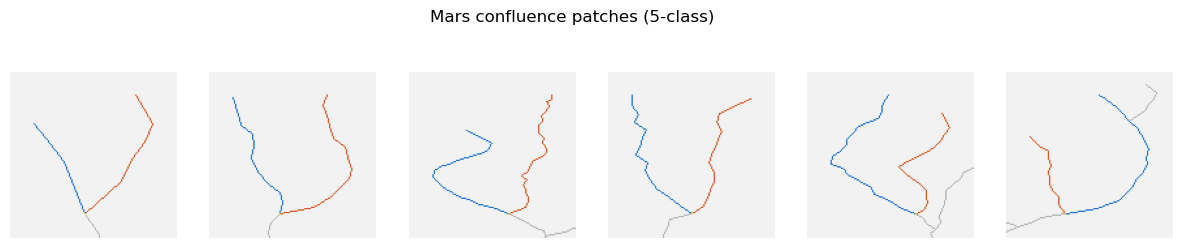

In [3]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap([[0.95,0.95,0.95],[0.85,0.33,0.10],[0.10,0.45,0.82],[0.70,0.70,0.70],[0.90,0.80,0.0]])
d = pd.read_parquet(MARS_IN / 'mars_cnn_patch_index.parquet')
col = 'patch_path' if 'patch_path' in d else 'raster_path'
ok = d[d.get('patch_status','ok') == 'ok'].head(6)
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, (_, row) in zip(axes, ok.iterrows()):
    a = np.load(_abs(row[col])); lab = a.argmax(0) if a.ndim == 3 else a
    ax.imshow(lab, cmap=cmap, vmin=0, vmax=4); ax.axis('off')
plt.suptitle('Mars confluence patches (5-class)'); plt.show()

### 3 · Do Earth and Mars CNN embeddings overlap? (domain check)

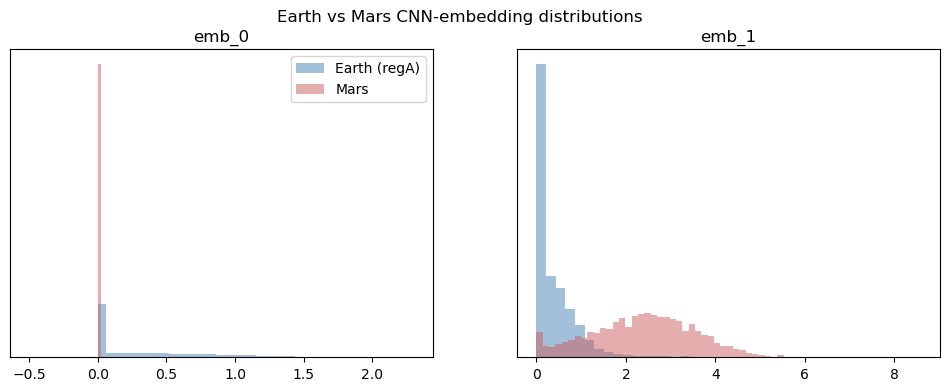

In [4]:
emb = MARS_IN / 'mars_cnn_embeddings.parquet'
if emb.exists():
    me = pd.read_parquet(emb)
    ee = pd.read_csv(RESULTS_DIR / 'master_dataset_regA_with_emb.csv')
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for i, a in enumerate(ax):
        a.hist(ee[f'emb_{i}'].dropna(), bins=40, density=True, alpha=0.5, label='Earth (regA)', color='steelblue')
        a.hist(me[f'emb_{i}'].dropna(), bins=40, density=True, alpha=0.5, label='Mars', color='indianred')
        a.set_title(f'emb_{i}'); a.set_yticks([])
    ax[0].legend(); plt.suptitle('Earth vs Mars CNN-embedding distributions'); plt.show()

**Takeaway.** Mars patches are regenerated under the exact 5-class contract and the
frozen production CNN, with the same pair coverage as before (3,682 ok / 103 invalid).
The Earth and Mars embedding distributions broadly overlap — the CNN is not being
asked to extrapolate into an unseen feature region, which is what makes the
cross-planet application defensible.